In [2]:
import os 
import sys
import pathlib

import numpy as np
import torch

from tqdm import tqdm
from matplotlib import pyplot as plt
from IPython.core.magic import register_cell_magic

os.environ['KERAS_BACKEND'] = 'torch'
import keras



In [3]:
import urllib.request
import zipfile
   
DATASET_DIR = pathlib.Path("jena")
file = "jena_climate_2009_2016.csv.zip"

if not DATASET_DIR.exists():
    urllib.request.urlretrieve(f"https://s3.amazonaws.com/keras-datasets/{file}", f"{file}")
    with zipfile.ZipFile(f"{file}", "r") as z:
        z.extractall("jena")


MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

In [4]:
fname = DATASET_DIR / "jena_climate_2009_2016.csv"

with open(fname) as f:
    data = f.read()
    
    
lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

for i, feature in enumerate(header):
    if feature == '"T (degC)"':
        print(f"{i:<2} | \033[1;3m]{feature} <- temp in deg C \033[0m")
    else:
        print(f"{i:<2} | {feature}")

print()
print(f"{len(lines)} lines")


0  | "Date Time"
1  | "p (mbar)"
2  | ]"T (degC)" <- temp in deg C 
3  | "Tpot (K)"
4  | "Tdew (degC)"
5  | "rh (%)"
6  | "VPmax (mbar)"
7  | "VPact (mbar)"
8  | "VPdef (mbar)"
9  | "sh (g/kg)"
10 | "H2OC (mmol/mol)"
11 | "rho (g/m**3)"
12 | "wv (m/s)"
13 | "max. wv (m/s)"
14 | "wd (deg)"

420451 lines


In [5]:
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

if not os.path.isfile(DATASET_DIR / 'temperate.npy') and not os.path.isfile(DATASET_DIR / "raw_data.npz"):
    for i, line in tqdm(enumerate(lines), total=len(lines)):
        values = [float(x) for x in line.split(",")[1:]]
        temperature[i] = values[1]
        raw_data[i,:] = values[:]
    np.save(DATASET_DIR / 'temperature.npy', temperature)
    np.save(DATASET_DIR / 'raw_data.npy', raw_data)
else:
    print("loading numpy files")
    temperature = np.load(DATASET_DIR / "temperature.npy")
    raw_data = np.load(DATASET_DIR / "raw_data.npy")

100%|██████████| 420451/420451 [00:01<00:00, 354707.36it/s]


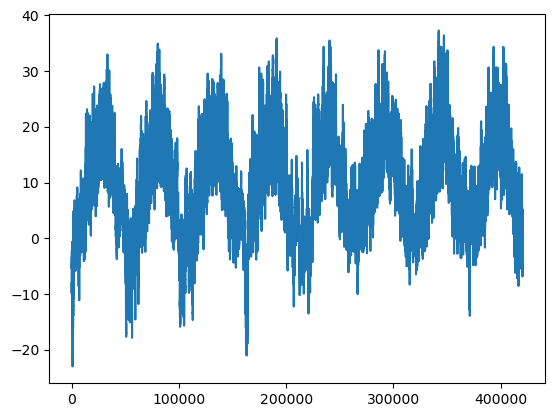

In [6]:
plt.plot(range(len(temperature)), temperature)

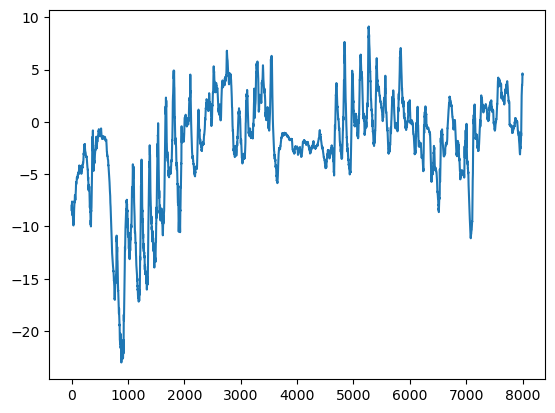

In [7]:
plt.plot(range(8000), temperature[:8000])

In [8]:
# 50% train, 25% val, 25% test

num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print(f"train: {num_train_samples}\nval: {num_val_samples}\ntest: {num_test_samples}")

train: 210225
val: 105112
test: 105114


In [9]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

raw_data = raw_data.astype(np.float32)
temperature = temperature.astype(np.float32)

In [10]:
# one sample every ten mins means six per hour
sampling_rate = 6
# 5 days (120 hours)
sequence_length = 120
# target is 24h after end of sequence
delay = sampling_rate * (sequence_length + 24 - 1)

BATCH_SIZE = 256

def make_dataset(start_index, end_index):
    return keras.utils.timeseries_dataset_from_array(
        data=raw_data[:-delay],
        targets=temperature[delay:],
        sampling_rate=sampling_rate,
        sequence_length=sequence_length,
        shuffle=True,
        batch_size = BATCH_SIZE,
        start_index = start_index,
        end_index=end_index
)

train_dataset = make_dataset(0, num_train_samples)
val_dataset = make_dataset(num_train_samples, num_train_samples + num_val_samples)
test_dataset = make_dataset(num_train_samples+num_val_samples, len(raw_data)-delay-1)

In [11]:
# Baseline: MAE (mean absolute error)

def eval_naive_method(dataset):
    total_abs_error = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_error += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]

    return total_abs_error / samples_seen

print(f"Val MAE: {eval_naive_method(val_dataset):.2f}")
print(f"Test MAE: {eval_naive_method(test_dataset):.2f}")


Val MAE: 2.44
Test MAE: 2.62


In [12]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = keras.layers.Reshape((sequence_length * raw_data.shape[-1],))(inputs)
x = keras.layers.Dense(16, activation='relu')(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,913 (105.13 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'jena_dense.keras'),
        save_best_only = True
    )
]

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_dataset,
    epochs=2,
    validation_data = val_dataset,
    callbacks = callbacks,
    verbose=0
)

In [15]:
model = keras.models.load_model(MODELS_DIR / "jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 11.6933 - mae: 2.6833
Test MAE: 2.68


In [16]:
def plot_history(history):
    loss = history.history['mae']
    val_loss = history.history['val_mae']
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, label='Training MAE')
    plt.plot(epochs, val_loss, label='VAL MAE')
    plt.title('Training and val MAE')
    plt.legend()
    plt.show()

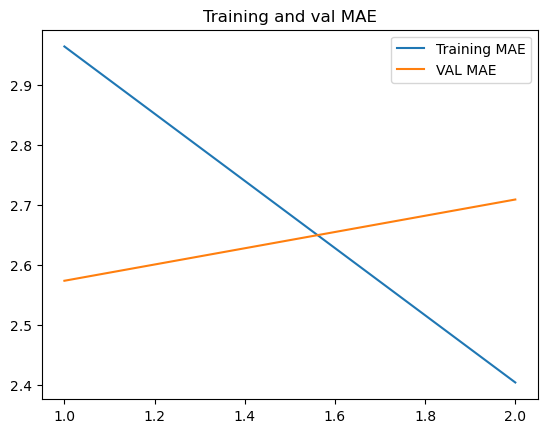

In [17]:
plot_history(history)

The machine is not privy to the wealth of human experiential evidence.

But why hasn't the machine found our simple model: that tomorrow's temperature will be pretty similar to today's?

The hypothesis space is the *space of all two layer networks*.

Already a very complicated space.

The simple baseline might be hidden in a tiny corner of this vast, intricate hypothesis space.

ML limitation: parameter learning can fail to find a simple solution to a simple problem.

Of course we could hard-code models to look for a specific kind of solution but we wish to avoid excessive feature engineering.


# RNN

In [18]:
keras.utils.clear_session()

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# LSTM
x = keras.layers.LSTM(16)(inputs)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [19]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'jena_lstm_bidirectional.keras'),
        save_best_only=True
    )
]

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=1,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

819/819 ━━━━━━━━━━━━━━━━━━━━ 217s 263ms/step - loss: 44.9975 - mae: 4.9551 - val_loss: 16.8687 - val_mae: 3.0626


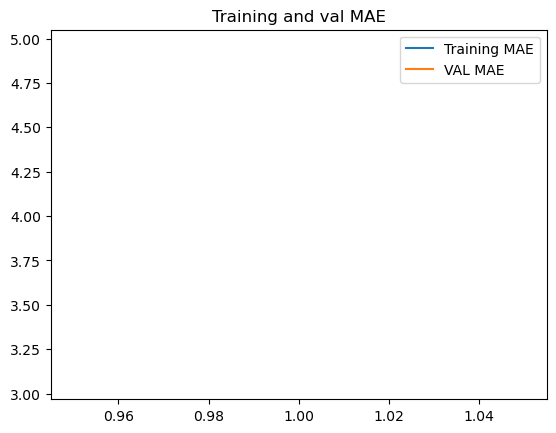

In [20]:
plot_history(history)

In [21]:
model = keras.models.load_model(MODELS_DIR / 'jena_lstm_bidirectional.keras')
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 64s 159ms/step - loss: 20.4620 - mae: 3.3064
Test MAE: 3.31


In [22]:
"""
RNN pseudocode

# State
state_t = 0

# Iterate over sequence elements
for input_t in input_sequence:
    # output_t = f(input_t, state_t)
    # that is:
    output_t = activation(dot(W, input_t) + dot(U, state_t) + b)

    # Output loops back to become state for next iter
    state_t = output_t
"""



'\nRNN pseudocode\n\n# State\nstate_t = 0\n\n# Iterate over sequence elements\nfor input_t in input_sequence:\n    # output_t = f(input_t, state_t)\n    # that is:\n    output_t = activation(dot(W, input_t) + dot(U, state_t) + b)\n\n    # Output loops back to become state for next iter\n    state_t = output_t\n'

so it does a feed forward but we also have a second set of weights (U) that also operates

In [23]:
# Naive RNN forward pass

import numpy as np
timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features))


# Weight matrices
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []

# input t is shape (input_features,)
for input_t in inputs:
    # combine input with current state (prev output)
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t

final_output_sequence = np.concatenate(successive_outputs, axis=0)



In [24]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(None, num_features))
outputs = keras.layers.SimpleRNN(16)(inputs)
print(outputs.shape)

(None, 16)


In [25]:
inputs = keras.Input(shape=(steps, num_features))
x = keras.layers.SimpleRNN(16, return_sequences=True)(inputs)
x = keras.layers.SimpleRNN(16, return_sequences=True)(x)
outputs = keras.layers.SimpleRNN(16)(x)

"If you want to get philosophical, you can interpret what each of these operations is meant to do. For instance, you can say that multiplying c_t and f_t is a way to deliberately forget irrelevant information in the carry dataflow. Meanwhile, i_t and k_t provide information about the present, updating the carry track with new information. But at the end of the day, these interpretations don’t mean much because what these operations actually do is determined by the contents of the weights parameterizing them, and the weights are learned in an end-to-end fashion, starting over with each training round, making it impossible to credit this or that operation with a specific purpose."
- https://deeplearningwithpython.io/chapters/chapter13_timeseries-forecasting/#recurrent-neural-networks

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        'jena_lstm_dropout.keras', save_best_only=True
    )
]

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=2,
    validation_data=val_dataset,
    callbacks=callbacks
)


Epoch 1/2
819/819 ━━━━━━━━━━━━━━━━━━━━ 434s 529ms/step - loss: 34.2052 - mae: 4.3176 - val_loss: 11.3695 - val_mae: 2.5790
Epoch 2/2
819/819 ━━━━━━━━━━━━━━━━━━━━ 353s 431ms/step - loss: 16.6720 - mae: 3.1638 - val_loss: 9.6293 - val_mae: 2.4028


In [27]:
# GRU
layers = keras.layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        'jena_stacked_gru_dropout.keras', save_best_only=True
    )
]

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

